# 03 — Análise Final e Gráficos
**Projeto:** budget-control-automation · **Etapa 3 de 3**

Depois de rodar a macro VBA no Excel (que gerou a aba `Variance_Report`),
usamos este notebook para ler o resultado e gerar os gráficos finais do README.

**Pré-requisito:** você já deve ter aberto `budget_control_data.xlsx`,
rodado a macro `RunBudgetControl` e salvo o arquivo.


## 1. Imports e carregamento da aba processada pelo VBA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CHARTS_PATH  = PROJECT_ROOT / "docs" / "screenshots"
CHARTS_PATH.mkdir(parents=True, exist_ok=True)

# Busca defensiva do arquivo Excel: tenta .xlsx, depois .xlsm,
# depois procura em qualquer subpasta do projeto.
# Isso evita erro se voce salvou como .xlsm (necessario p/ manter a macro).

candidatos = [
    PROCESSED_DIR / "budget_control_data.xlsx",
    PROCESSED_DIR / "budget_control_data.xlsm",
]

XLSX_PATH = None
for c in candidatos:
    if c.exists():
        XLSX_PATH = c
        break

if XLSX_PATH is None:
    encontrados = list(PROJECT_ROOT.rglob("budget_control_data.*"))
    encontrados = [f for f in encontrados if f.suffix in [".xlsx", ".xlsm"]]
    if encontrados:
        XLSX_PATH = encontrados[0]

if XLSX_PATH is None:
    print("=" * 60)
    print("  ARQUIVO NAO ENCONTRADO - diagnostico:")
    print("=" * 60)
    print(f"  Pasta raiz do projeto (calculada): {PROJECT_ROOT}")
    print(f"  Pasta processed esperada: {PROCESSED_DIR}")
    print(f"  Essa pasta existe? {PROCESSED_DIR.exists()}")
    if PROCESSED_DIR.exists():
        print(f"  Arquivos encontrados dentro dela:")
        for f in PROCESSED_DIR.iterdir():
            print(f"    - {f.name}")
    else:
        print("  A pasta data/processed nem existe nesse caminho.")
    raise FileNotFoundError(
        "Nao encontrei budget_control_data.xlsx nem .xlsm. "
        "Veja o diagnostico acima e confira a secao de troubleshooting do guia."
    )

print(f"Arquivo encontrado em: {XLSX_PATH}")
print(f"Extensao: {XLSX_PATH.suffix}")

df = pd.read_excel(XLSX_PATH, sheet_name="Variance_Report", skiprows=0)
df = df[df["Actual_Sales"].notna()].copy()
print(f"Linhas carregadas: {len(df)}")
df.head()

Arquivo encontrado em: c:\Users\arthu\Documents\GitHub\budget-control-automation\data\processed\budget_control_data.xlsm
Extensao: .xlsm
Linhas carregadas: 144


,Month,Category,Actual_Sales,Budget_Sales,Variance_R$,Variance_%,Status
0,2014-01,Furniture,6242.53,17328.82,-11086.29,-64.0,Abaixo do orçamento
1,2014-02,Furniture,1839.66,6432.49,-4592.83,-71.4,Abaixo do orçamento
2,2014-03,Furniture,14573.96,4248.72,10325.24,243.0,Acima do orçamento
3,2014-04,Furniture,7944.84,8058.91,-114.07,-1.4,Abaixo do orçamento
4,2014-05,Furniture,6912.79,8256.42,-1343.63,-16.3,Abaixo do orçamento


## 2. Se você ainda não rodou a macro VBA

Caso queira gerar os gráficos antes de rodar a macro no Excel (para testar
o notebook), esta célula alternativa replica o cálculo da variância em Python:


In [2]:
# ── Alternativa: calcular a variância em Python (caso a macro VBA ainda não tenha rodado) ──
# Comentário: descomente e rode esta célula SE a aba Variance_Report estiver vazia

USAR_ALTERNATIVA_PYTHON = False   # mude para True se necessário

if USAR_ALTERNATIVA_PYTHON:
    actual = pd.read_excel(XLSX_PATH, sheet_name="Actual")
    budget = pd.read_excel(XLSX_PATH, sheet_name="Budget")
    df = actual.merge(budget, on=["Month", "Category"])
    df["Variance_R$"] = df["Actual_Sales"] - df["Budget_Sales"]
    df["Variance_%"] = (df["Variance_R$"] / df["Budget_Sales"] * 100).round(1)
    df["Status"] = np.where(df["Variance_%"] >= 0, "Acima do orçamento", "Abaixo do orçamento")
    print("Variância calculada via Python (fallback)")
    print(df.head())

## 3. Gráfico A — Variância percentual por categoria ao longo do tempo

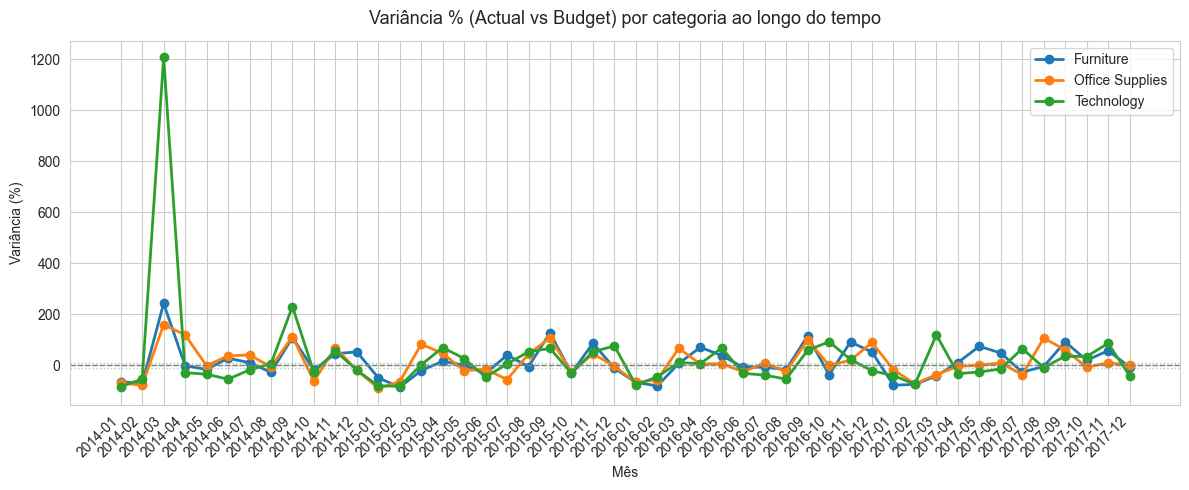

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

for cat in df["Category"].unique():
    subset = df[df["Category"] == cat].sort_values("Month")
    ax.plot(subset["Month"], subset["Variance_%"], marker="o", label=cat, linewidth=2)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axhline(10, color="#55A868", linestyle=":", linewidth=1, alpha=0.5)
ax.axhline(-10, color="#55A868", linestyle=":", linewidth=1, alpha=0.5)
ax.set_title("Variância % (Actual vs Budget) por categoria ao longo do tempo", fontsize=13, pad=12)
ax.set_ylabel("Variância (%)")
ax.set_xlabel("Mês")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHARTS_PATH / "budget_variance_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Gráfico B — Distribuição de status (dentro/fora do orçamento)

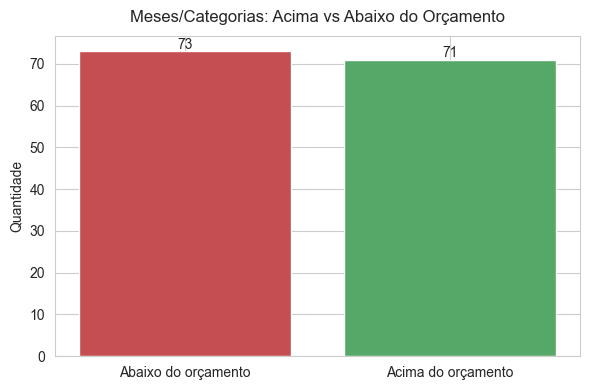

In [4]:
status_counts = df["Status"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#55A868" if "Acima" in s else "#C44E52" for s in status_counts.index]
ax.bar(status_counts.index, status_counts.values, color=colors, edgecolor="white")
ax.set_title("Meses/Categorias: Acima vs Abaixo do Orçamento", fontsize=12, pad=10)
ax.set_ylabel("Quantidade")
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(CHARTS_PATH / "budget_status_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Gráfico C — Desvio médio absoluto por categoria

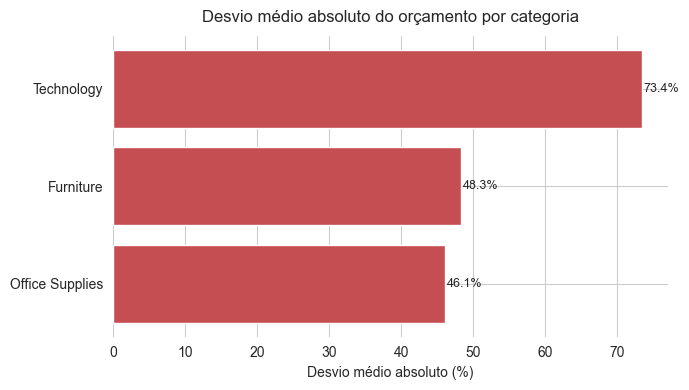

In [5]:
avg_deviation = df.groupby("Category")["Variance_%"].apply(lambda x: x.abs().mean()).round(1).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#55A868" if v <= 15 else "#DD8452" if v <= 25 else "#C44E52" for v in avg_deviation.values]
ax.barh(avg_deviation.index, avg_deviation.values, color=colors, edgecolor="white")
for i, v in enumerate(avg_deviation.values):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)
ax.set_title("Desvio médio absoluto do orçamento por categoria", fontsize=12, pad=10)
ax.set_xlabel("Desvio médio absoluto (%)")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig(CHARTS_PATH / "budget_avg_deviation.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Resumo executivo e exportação final

In [6]:
kpi = df.groupby("Category").agg(
    total_actual=("Actual_Sales", "sum"),
    total_budget=("Budget_Sales", "sum"),
    avg_deviation_pct=("Variance_%", lambda x: round(x.abs().mean(), 1))
).reset_index()
kpi["overall_variance_pct"] = round(
    (kpi["total_actual"] - kpi["total_budget"]) / kpi["total_budget"] * 100, 1
)

KPI_PATH = PROJECT_ROOT / "data" / "processed" / "budget_kpi_summary.csv"
kpi.to_csv(KPI_PATH, index=False)

print("=" * 55)
print("  BUDGET CONTROL AUTOMATION — RESUMO EXECUTIVO")
print("=" * 55)
print(kpi.to_string(index=False))
print()
print(f"Desvio médio geral: {df['Variance_%'].abs().mean():.1f}%")
print(f"KPI exportado para: {KPI_PATH}")
print()
print("Gráficos gerados em docs/screenshots/:")
for f in sorted(CHARTS_PATH.glob('budget_*.png')):
    print(f"  {f.name}")

  BUDGET CONTROL AUTOMATION — RESUMO EXECUTIVO
       Category  total_actual  total_budget  avg_deviation_pct  overall_variance_pct
      Furniture     741999.81     734079.22               48.3                   1.1
Office Supplies     719047.04     706518.58               46.1                   1.8
     Technology     836154.01     835083.13               73.4                   0.1

Desvio médio geral: 55.9%
KPI exportado para: c:\Users\arthu\Documents\GitHub\budget-control-automation\data\processed\budget_kpi_summary.csv

Gráficos gerados em docs/screenshots/:
  budget_avg_deviation.png
  budget_status_distribution.png
  budget_variance_trend.png
